In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# tune the lr and n_iters hyperparameters 
# try n_iters = 60, 100, 250, 500 & lr = 0.01, 0.001, 0.05, 0.1

learning_rate = 0.01
n_iters = 200
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, n_iters=500):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        self.loss_history = []

    def initialize_parameters(self, n_features):
        self.weights = np.zeros(n_features)
        self.bias = 0

    def compute_mse(self, y, y_pred):
        return np.mean((y - y_pred) ** 2)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.initialize_parameters(n_features)

        for _ in range(self.n_iters):
            y_pred = np.dot(X, self.weights) + self.bias

            dw = (2 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (2 / n_samples) * np.sum(y_pred - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            loss = self.compute_mse(y, y_pred)
            self.loss_history.append(loss)

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias
    

Weights: [2.31963163]
Bias: 1.8460283941213853
Prediction for 6: [15.76381818]


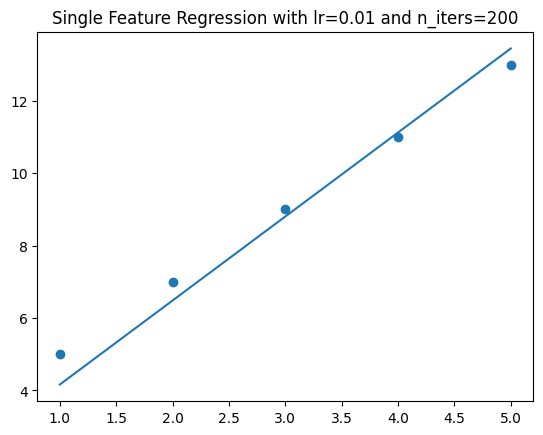

In [ ]:
# y = 2x + 3
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([5, 7, 9, 11, 13])   

model = LinearRegressionGD(learning_rate=learning_rate, n_iters=n_iters)
model.fit(X, y)

print("Weights:", model.weights)
print("Bias:", model.bias)

x_test = np.array([[6]])
print("Prediction for 6:", model.predict(x_test))

plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.title(f"Single Feature Regression with lr={learning_rate} and n_iters={n_iters}")
plt.show()

In [8]:

# y = 3*x1 + 2*x2 + 5
X_multi = np.array([
    [1, 2],
    [2, 1],
    [3, 4],
    [4, 3],
    [5, 5]
])

y_multi = np.array([3*row[0] + 2*row[1] + 5 for row in X_multi])

model_multi = LinearRegressionGD(learning_rate=learning_rate, n_iters=n_iters)
model_multi.fit(X_multi, y_multi)

print("Weights:", model_multi.weights)
print("Bias:", model_multi.bias)


Weights: [3.20419584 2.40479746]
Bias: 2.8239076991049656


Weights: [-36404.76665669  46846.69873615 113915.18571196 -20144.16278745
  22667.28720686  30788.38496626  41381.98603551  24198.38786226
 103582.33955049  43992.19397108 -61423.17867996   9380.73694421]
Bias: 542255.0929036132
MSE: 248994413110.15213
RMSE: 498993.399866323


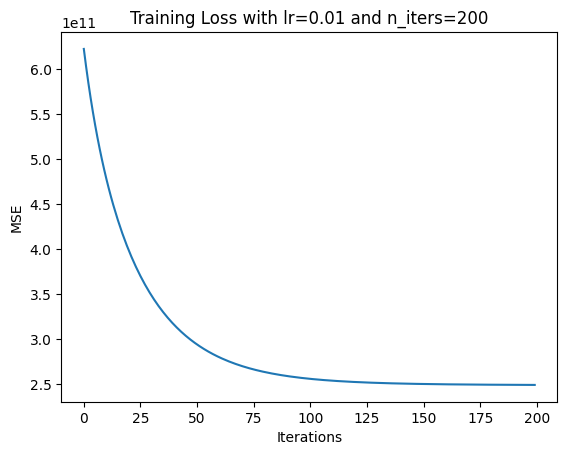

In [9]:
# numeric data only
df = pd.read_csv("house_price.csv")

df = df.drop(columns=["date", "street", "city", "statezip", "country"])

X = df.drop(columns=["price"]).values
y = df["price"].values

mean = X.mean(axis=0)
std = X.std(axis=0)
std[std == 0] = 1
X_scaled = (X - mean) / std

model = LinearRegressionGD(learning_rate=learning_rate, n_iters=n_iters)
model.fit(X_scaled, y)

print("Weights:", model.weights)
print("Bias:", model.bias)

y_pred = model.predict(X_scaled)

mse = np.mean((y - y_pred) ** 2)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

plt.plot(model.loss_history)
plt.title(f"Training Loss with lr={learning_rate} and n_iters={n_iters}")
plt.xlabel("Iterations")
plt.ylabel("MSE")
plt.show()


Weights: [-18847.06043197  30753.88757429  94310.03885955   3541.8778601
 -11986.47163422  39130.94932738  42796.32978707  17343.97783486
  94706.71037713  19793.4867154  -11359.93816567   6256.68442981
      0.          14141.47980978  -1652.4095212  -29401.56201037
  -1538.46101271  26251.69210968  -2897.28779249  -3158.49998534
  -9809.79269004  -2914.54542773   1854.4057055   -2355.47378243
 -10041.78014604  -5658.83577957  -8982.53791734   -248.59719695
 -21886.65954011    453.35396306  -1091.94649149  -3813.41605354
  -7958.81639615   9069.63795432  -6840.94148284 -12679.30740527
  26870.68424208  20118.19259599  -1016.03095112   5819.7743834
  -1511.94551017  -6019.29068894  -2984.32970266   -824.76993888
  -1927.72187875   7508.76325035 -20128.15165741   2220.34384984
  -4353.77074992  27360.05732509  -2294.5347494   -1894.22140429
  -7139.17973361    266.15389393    302.29465419  -8067.45335225
  -1896.66180954   3484.0923142   -6159.60756004  -8658.63794117
  59311.14306149  

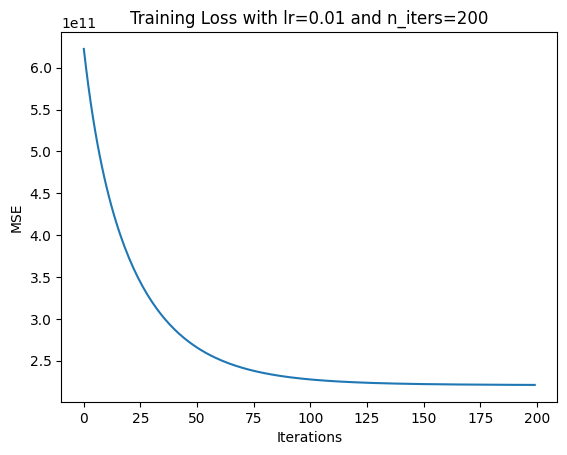

In [10]:
# all features
df = pd.read_csv("house_price.csv")

df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df = df.drop(columns=["date"])

df = pd.get_dummies(df, columns=["city", "statezip", "country"], drop_first=True)

df = df.drop(columns=["street"])

df = df.apply(pd.to_numeric)

X = df.drop(columns=["price"]).astype(np.float64).values
y = df["price"].astype(np.float64).values

mean = X.mean(axis=0)
std = X.std(axis=0)
std[std == 0] = 1
X_scaled = (X - mean) / std

model = LinearRegressionGD(learning_rate=learning_rate, n_iters=n_iters)
model.fit(X_scaled, y)

print("Weights:", model.weights)
print("Bias:", model.bias)

y_pred = model.predict(X_scaled)

mse = np.mean((y - y_pred) ** 2)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

plt.plot(model.loss_history)
plt.title(f"Training Loss with lr={learning_rate} and n_iters={n_iters}")
plt.xlabel("Iterations")
plt.ylabel("MSE")
plt.show()

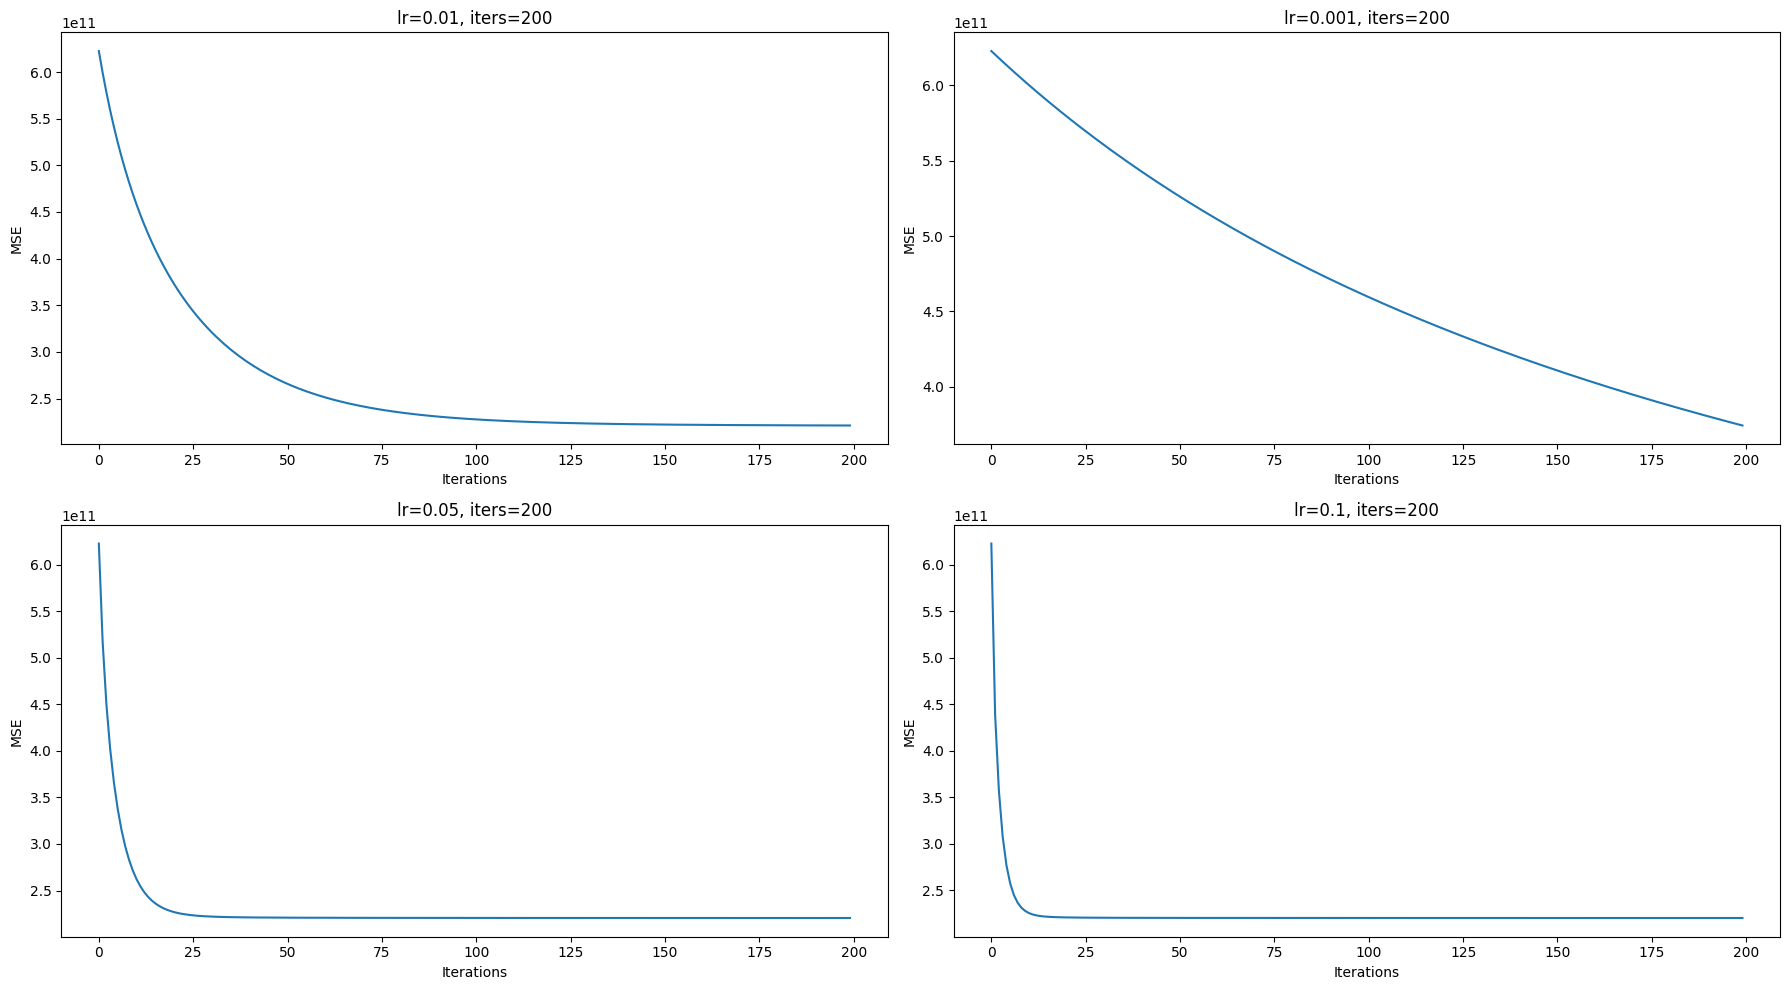

In [16]:
lrs = [0.01, 0.001, 0.05, 0.1]
n_iter = 200

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

results = {}

for idx, lr in enumerate(lrs):

    row = idx // 2
    col = idx % 2

    model = LinearRegressionGD(learning_rate=lr, n_iters=n_iter)
    model.fit(X_scaled, y)

    final_loss = model.loss_history[-1]
    results[(lr, n_iter)] = final_loss

    ax = axes[row, col]
    ax.plot(model.loss_history)
    ax.set_title(f"lr={lr}, iters={n_iter}")
    ax.set_xlabel("Iterations")
    ax.set_ylabel("MSE")

plt.tight_layout()
plt.show()

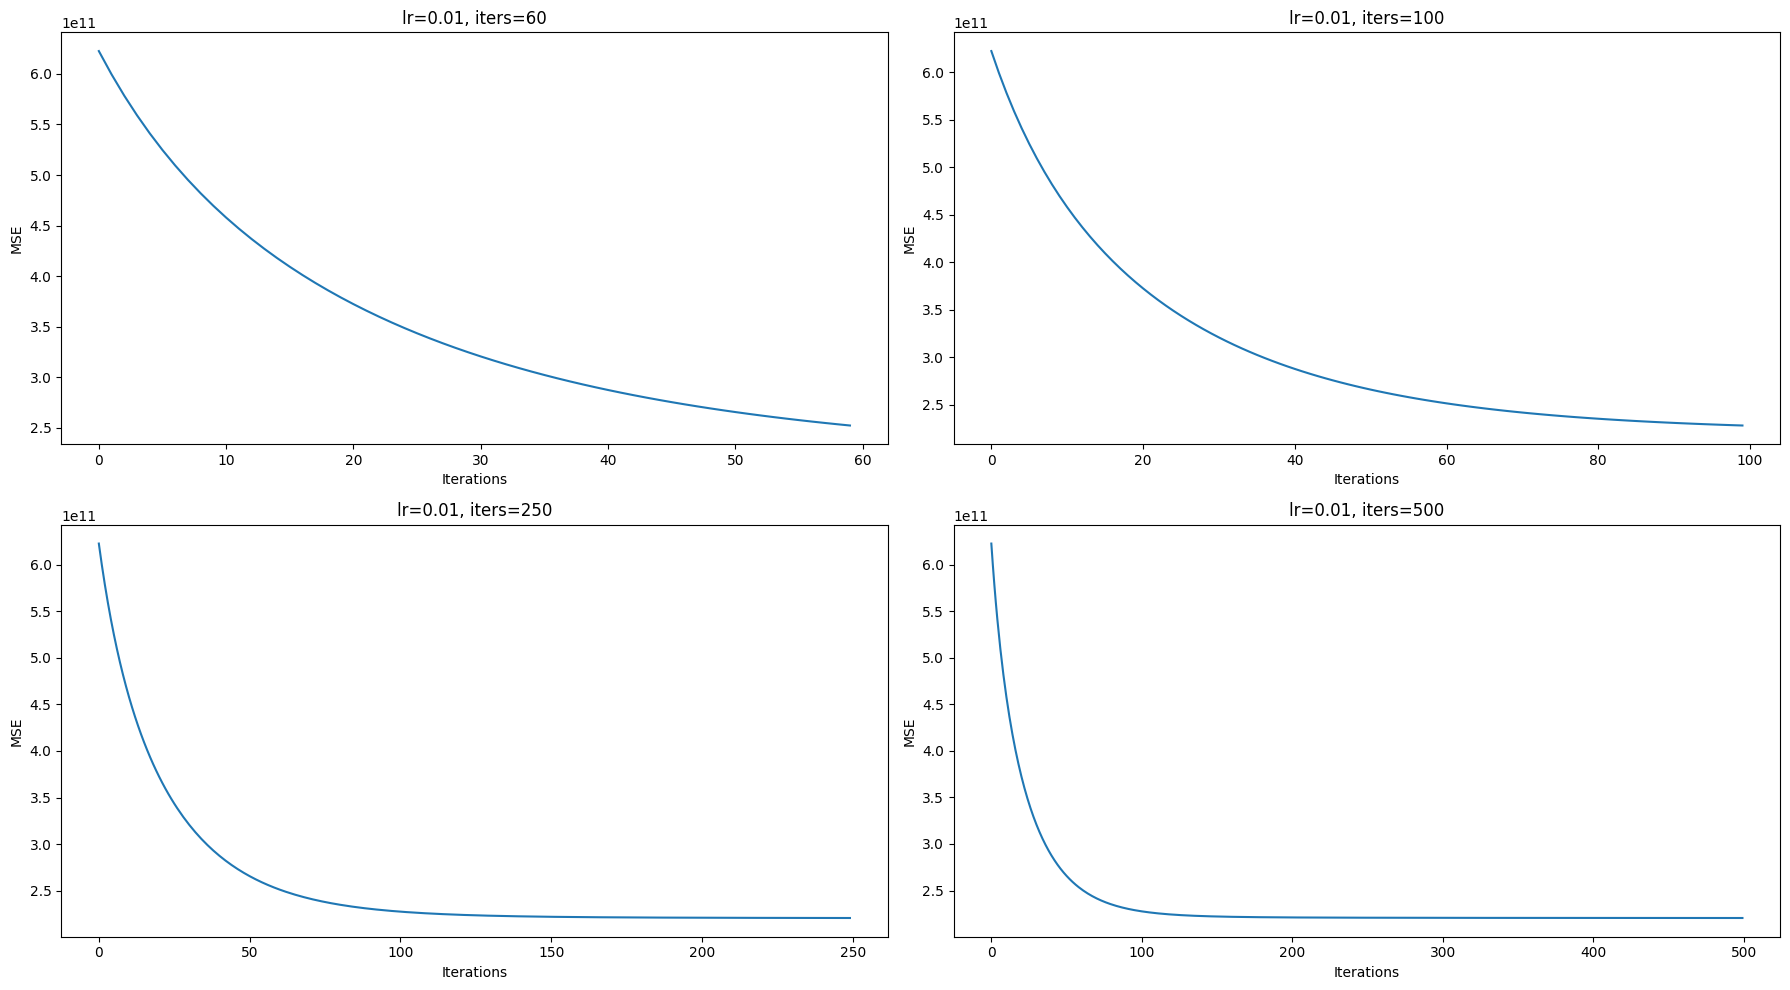

In [17]:
iters_list = [60, 100, 250, 500]
lr = 0.01

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

results = {}

for idx, n_iter in enumerate(iters_list):

    row = idx // 2
    col = idx % 2

    model = LinearRegressionGD(learning_rate=lr, n_iters=n_iter)
    model.fit(X_scaled, y)

    final_loss = model.loss_history[-1]
    results[(lr, n_iter)] = final_loss

    ax = axes[row, col]
    ax.plot(model.loss_history)
    ax.set_title(f"lr={lr}, iters={n_iter}")
    ax.set_xlabel("Iterations")
    ax.set_ylabel("MSE")

plt.tight_layout()
plt.show()